# DDPM Inpainting

In [6]:
from pathlib import Path

import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import cv2

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from tqdm.auto import tqdm

In [7]:
# Reproducibility + device
SEED = 123

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("PyTorch version:", torch.__version__)

Device: cpu
PyTorch version: 2.12.0


In [8]:
# ---------------------------------------------------
# Dataset paths
# ---------------------------------------------------

DATA_DIR = Path("../data/raw/retinal-oct-c8/RetinalOCT_Dataset/RetinalOCT_Dataset")

TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"
TEST_DIR = DATA_DIR / "test"

train_paths = sorted(list(TRAIN_DIR.glob("*/*.jpg")))
val_paths = sorted(list(VAL_DIR.glob("*/*.jpg")))
test_paths = sorted(list(TEST_DIR.glob("*/*.jpg")))

print(f"Train images: {len(train_paths)}")
print(f"Val images:   {len(val_paths)}")
print(f"Test images:  {len(test_paths)}")

Train images: 18400
Val images:   2800
Test images:  2800


In [9]:
# Preprocessing
TARGET_SIZE = (256, 128)

def preprocess_image(path, target_size=TARGET_SIZE):
    img = Image.open(path).convert("L")
    img = img.resize(
        target_size,
        resample=Image.BILINEAR
    )
    
    arr = np.array(img).astype(np.float32)
    arr = arr / 255.0
    return arr

# Stripe mask
def horizontal_stripe_mask(shape, stripe_height=24):
    h, w = shape
    mask = np.ones((h, w), dtype=np.float32)
    center = h // 2
    top = center - stripe_height // 2
    mask[top:top+stripe_height, :] = 0.0
    return mask

In [10]:
# PyTorch dataset for DDPM inpainting
class OCTInpaintingDataset(Dataset):
    
    def __init__(
        self,
        image_paths,
        preprocess_fn,
        mask_fn
    ):
        self.image_paths = image_paths
        self.preprocess_fn = preprocess_fn
        self.mask_fn = mask_fn
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        
        path = self.image_paths[idx]
        
        img = self.preprocess_fn(path)
        mask = self.mask_fn(img.shape)
        masked_img = img * mask
        
        img = torch.tensor(img).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()
        masked_img = torch.tensor(masked_img).unsqueeze(0).float()
        
        return {
            "image": img,
            "mask": mask,
            "masked_image": masked_img
        }

In [11]:
# Data loaders
BATCH_SIZE = 8

train_dataset = OCTInpaintingDataset(
    image_paths=train_paths,
    preprocess_fn=preprocess_image,
    mask_fn=horizontal_stripe_mask
)

val_dataset = OCTInpaintingDataset(
    image_paths=val_paths,
    preprocess_fn=preprocess_image,
    mask_fn=horizontal_stripe_mask
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

batch = next(iter(train_loader))

for key, value in batch.items():
    print(key, value.shape)

image torch.Size([8, 1, 128, 256])
mask torch.Size([8, 1, 128, 256])
masked_image torch.Size([8, 1, 128, 256])


In [12]:
# Diffusion hyperparameters
T = 1000
beta_start = 1e-4
beta_end = 2e-2

betas = torch.linspace(
    beta_start,
    beta_end,
    T
).to(device)

alphas = 1.0 - betas
alpha_bars = torch.cumprod(
    alphas,
    dim=0
)

print("Betas shape:", betas.shape)
print("Alpha bars shape:", alpha_bars.shape)

print()
print("beta_start:", betas[0].item())
print("beta_end:", betas[-1].item())

Betas shape: torch.Size([1000])
Alpha bars shape: torch.Size([1000])

beta_start: 9.999999747378752e-05
beta_end: 0.019999999552965164


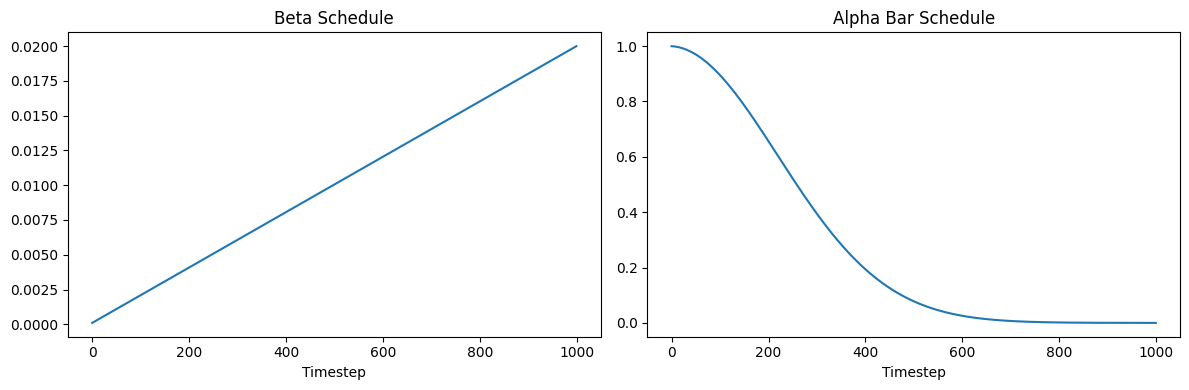

In [13]:
# Visualize diffusion schedule
fig, axes = plt.subplots(1, 2, figsize=(12,4))

axes[0].plot(
    betas.cpu().numpy()
)

axes[0].set_title("Beta Schedule")
axes[0].set_xlabel("Timestep")

axes[1].plot(
    alpha_bars.cpu().numpy()
)

axes[1].set_title("Alpha Bar Schedule")
axes[1].set_xlabel("Timestep")

plt.tight_layout()
plt.show()

In [14]:
# Forward diffusion process
def q_sample(x0, t, noise=None):
    
    if noise is None:
        noise = torch.randn_like(x0)
    
    sqrt_alpha_bar_t = torch.sqrt(alpha_bars[t]).view(-1, 1, 1, 1)
    sqrt_one_minus_alpha_bar_t = torch.sqrt(1.0 - alpha_bars[t]).view(-1, 1, 1, 1)
    
    return (
        sqrt_alpha_bar_t * x0
        +
        sqrt_one_minus_alpha_bar_t * noise
    )

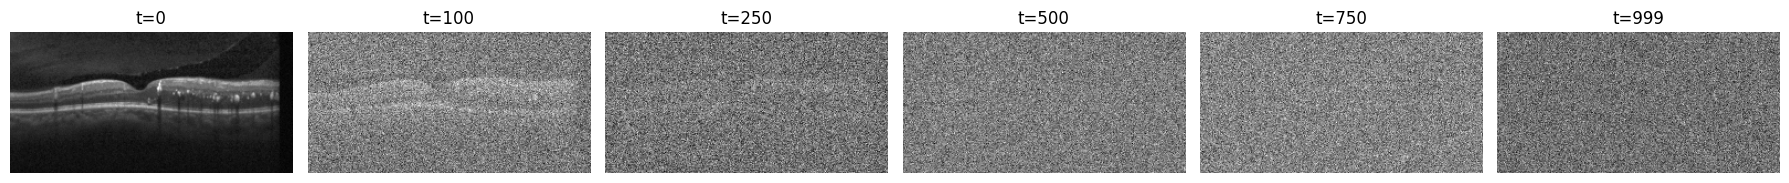

In [15]:
# Visualize forward diffusion

x0 = batch["image"][:1].to(device)

timesteps = [0, 100, 250, 500, 750, 999]

fig, axes = plt.subplots(1, len(timesteps), figsize=(18, 3))

for i, timestep in enumerate(timesteps):
    
    t = torch.tensor([timestep], device=device).long()
    
    xt = q_sample(x0, t)
    
    axes[i].imshow(
        xt[0, 0].detach().cpu().numpy(),
        cmap="gray"
    )
    
    axes[i].set_title(f"t={timestep}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [16]:
# Simple DDPM model

class SimpleDDPM(nn.Module):
    
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
        )
        
        self.decoder = nn.Sequential(
            nn.Conv2d(64, 64, 3, padding=1),
            nn.ReLU(),
            
            nn.Conv2d(64, 32, 3, padding=1),
            nn.ReLU(),
            
            nn.Conv2d(32, 1, 3, padding=1),
        )
        
    def forward(self, x, t):
        
        h = self.encoder(x)
        
        out = self.decoder(h)
        
        return out

In [17]:
# Initialize model

model = SimpleDDPM().to(device)

n_params = sum(
    p.numel()
    for p in model.parameters()
)

print(model)

print()
print(f"Parameters: {n_params:,}")

SimpleDDPM(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  )
)

Parameters: 111,425


In [18]:
# Forward pass sanity check

x0 = batch["image"].to(device)

batch_size = x0.shape[0]

t = torch.randint(
    low=0,
    high=T,
    size=(batch_size,),
    device=device
).long()

noise = torch.randn_like(x0)

xt = q_sample(x0, t, noise)

pred_noise = model(xt, t)

print("x0:", x0.shape)
print("xt:", xt.shape)
print("noise:", noise.shape)
print("predicted noise:", pred_noise.shape)

x0: torch.Size([8, 1, 128, 256])
xt: torch.Size([8, 1, 128, 256])
noise: torch.Size([8, 1, 128, 256])
predicted noise: torch.Size([8, 1, 128, 256])


In [19]:
# Training setup

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

loss_fn = nn.MSELoss()

In [20]:
# Tiny training sanity check

model.train()

n_steps = 25
losses = []

data_iter = iter(train_loader)

for step in range(n_steps):
    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        batch = next(data_iter)
    
    x0 = batch["image"].to(device)
    
    batch_size = x0.shape[0]
    
    t = torch.randint(
        0,
        T,
        (batch_size,),
        device=device
    ).long()
    
    noise = torch.randn_like(x0)
    
    xt = q_sample(x0, t, noise)
    
    pred_noise = model(xt, t)
    
    loss = loss_fn(pred_noise, noise)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses.append(loss.item())
    
    print(f"Step {step+1:03d} | Loss: {loss.item():.6f}")

Step 001 | Loss: 1.000350
Step 002 | Loss: 1.002672
Step 003 | Loss: 0.997393
Step 004 | Loss: 0.998315
Step 005 | Loss: 0.993946
Step 006 | Loss: 0.994244
Step 007 | Loss: 0.996304
Step 008 | Loss: 0.991351
Step 009 | Loss: 0.991359
Step 010 | Loss: 0.989651
Step 011 | Loss: 0.984531
Step 012 | Loss: 0.983617
Step 013 | Loss: 0.983368
Step 014 | Loss: 0.973603
Step 015 | Loss: 0.975486
Step 016 | Loss: 0.979986
Step 017 | Loss: 0.967887
Step 018 | Loss: 0.963398
Step 019 | Loss: 0.959906
Step 020 | Loss: 0.957077
Step 021 | Loss: 0.954940
Step 022 | Loss: 0.945278
Step 023 | Loss: 0.935692
Step 024 | Loss: 0.930291
Step 025 | Loss: 0.917170


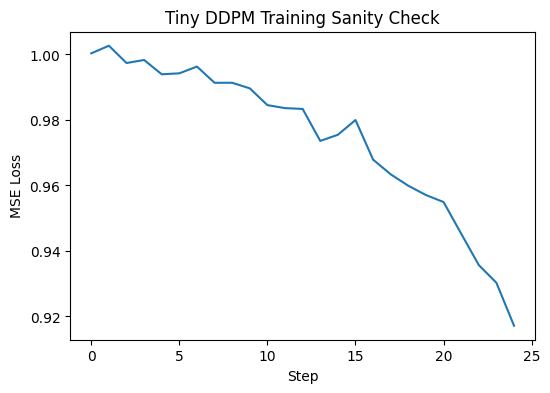

In [21]:
plt.figure(figsize=(6, 4))

plt.plot(losses)

plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Tiny DDPM Training Sanity Check")

plt.show()

In [22]:
# Sinusoidal timestep embedding

class SinusoidalPositionEmbeddings(nn.Module):
    
    def __init__(self, dim):
        super().__init__()
        self.dim = dim
    
    def forward(self, time):
        
        device = time.device
        
        half_dim = self.dim // 2
        
        embeddings = math.log(10000) / (half_dim - 1)
        
        embeddings = torch.exp(
            torch.arange(
                half_dim,
                device=device
            ) * -embeddings
        )
        
        embeddings = time[:, None] * embeddings[None, :]
        
        embeddings = torch.cat(
            (
                embeddings.sin(),
                embeddings.cos()
            ),
            dim=-1
        )
        
        return embeddings

In [23]:
# DDPM with timestep conditioning

class TimeConditionedDDPM(nn.Module):
    
    def __init__(self, time_emb_dim=32):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        self.conv1 = nn.Conv2d(1, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        
        self.deconv1 = nn.Conv2d(64, 64, 3, padding=1)
        self.deconv2 = nn.Conv2d(64, 32, 3, padding=1)
        self.deconv3 = nn.Conv2d(32, 1, 3, padding=1)
        
        self.relu = nn.ReLU()
        
        self.time_proj = nn.Linear(time_emb_dim, 64)
    
    def forward(self, x, t):
        
        # Time embedding
        t_emb = self.time_mlp(t.float())
        
        # Encoder
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        h = self.relu(self.conv3(h))
        
        # Inject timestep information
        t_proj = self.time_proj(t_emb)
        
        t_proj = t_proj[:, :, None, None]
        
        h = h + t_proj
        
        # Decoder
        h = self.relu(self.deconv1(h))
        h = self.relu(self.deconv2(h))
        
        out = self.deconv3(h)
        
        return out

In [24]:
model = TimeConditionedDDPM().to(device)

n_params = sum(
    p.numel()
    for p in model.parameters()
)

print(model)

print()
print(f"Parameters: {n_params:,}")

TimeConditionedDDPM(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
  )
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv3): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (time_proj): Linear(in_features=32, out_features=64, bias=True)
)

Parameters: 114,593


In [25]:
# Forward pass sanity check for time-conditioned model

batch = next(iter(train_loader))

x0 = batch["image"].to(device)

batch_size = x0.shape[0]

t = torch.randint(
    0,
    T,
    (batch_size,),
    device=device
).long()

noise = torch.randn_like(x0)

xt = q_sample(x0, t, noise)

pred_noise = model(xt, t)

print("x0:", x0.shape)
print("xt:", xt.shape)
print("t:", t.shape)
print("noise:", noise.shape)
print("predicted noise:", pred_noise.shape)

x0: torch.Size([8, 1, 128, 256])
xt: torch.Size([8, 1, 128, 256])
t: torch.Size([8])
noise: torch.Size([8, 1, 128, 256])
predicted noise: torch.Size([8, 1, 128, 256])


In [26]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

model.train()

n_steps = 50
losses_time_conditioned = []

data_iter = iter(train_loader)

for step in range(n_steps):
    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        batch = next(data_iter)
    
    x0 = batch["image"].to(device)
    batch_size = x0.shape[0]
    
    t = torch.randint(0, T, (batch_size,), device=device).long()
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)
    
    pred_noise = model(xt, t)
    loss = loss_fn(pred_noise, noise)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses_time_conditioned.append(loss.item())
    
    print(f"Step {step+1:03d} | Loss: {loss.item():.6f}")

Step 001 | Loss: 1.000071
Step 002 | Loss: 0.998376
Step 003 | Loss: 1.000859
Step 004 | Loss: 0.996956
Step 005 | Loss: 0.998266
Step 006 | Loss: 0.998111
Step 007 | Loss: 0.992571
Step 008 | Loss: 0.988155
Step 009 | Loss: 0.986122
Step 010 | Loss: 0.984386
Step 011 | Loss: 0.986086
Step 012 | Loss: 0.980956
Step 013 | Loss: 0.985618
Step 014 | Loss: 0.980673
Step 015 | Loss: 0.967295
Step 016 | Loss: 0.964725
Step 017 | Loss: 0.974045
Step 018 | Loss: 0.958161
Step 019 | Loss: 0.958526
Step 020 | Loss: 0.947775
Step 021 | Loss: 0.941061
Step 022 | Loss: 0.933900
Step 023 | Loss: 0.940428
Step 024 | Loss: 0.915796
Step 025 | Loss: 0.910325
Step 026 | Loss: 0.924297
Step 027 | Loss: 0.893774
Step 028 | Loss: 0.904356
Step 029 | Loss: 0.884507
Step 030 | Loss: 0.877109
Step 031 | Loss: 0.839861
Step 032 | Loss: 0.833183
Step 033 | Loss: 0.831067
Step 034 | Loss: 0.811404
Step 035 | Loss: 0.806195
Step 036 | Loss: 0.791102
Step 037 | Loss: 0.777815
Step 038 | Loss: 0.714794
Step 039 | L

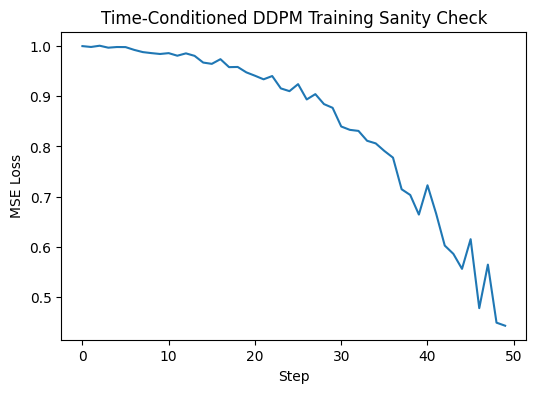

In [27]:
plt.figure(figsize=(6, 4))
plt.plot(losses_time_conditioned)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Time-Conditioned DDPM Training Sanity Check")
plt.show()

In [28]:
model.train()

n_steps = 200
losses_extended = []

data_iter = iter(train_loader)

for step in range(n_steps):
    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(train_loader)
        batch = next(data_iter)
    
    x0 = batch["image"].to(device)
    batch_size = x0.shape[0]
    
    t = torch.randint(0, T, (batch_size,), device=device).long()
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)
    
    pred_noise = model(xt, t)
    loss = loss_fn(pred_noise, noise)
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    losses_extended.append(loss.item())
    
    if (step + 1) % 25 == 0:
        print(f"Step {step+1:03d} | Loss: {loss.item():.6f}")

Step 025 | Loss: 0.087325
Step 050 | Loss: 0.134203
Step 075 | Loss: 0.079425
Step 100 | Loss: 0.034418
Step 125 | Loss: 0.132121
Step 150 | Loss: 0.145629
Step 175 | Loss: 0.123873
Step 200 | Loss: 0.084032


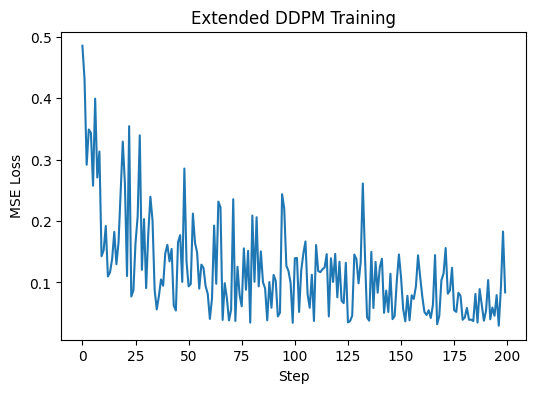

In [29]:
plt.figure(figsize=(6, 4))
plt.plot(losses_extended)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Extended DDPM Training")
plt.show()

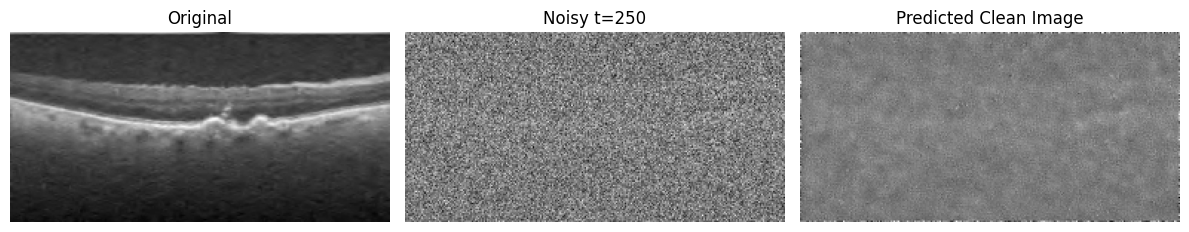

In [30]:
model.eval()

with torch.no_grad():
    batch = next(iter(val_loader))
    
    x0 = batch["image"][:1].to(device)
    
    t = torch.tensor([250], device=device).long()
    noise = torch.randn_like(x0)
    xt = q_sample(x0, t, noise)
    
    pred_noise = model(xt, t)
    
    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)
    
    x0_pred = (
        xt - torch.sqrt(1.0 - alpha_bar_t) * pred_noise
    ) / torch.sqrt(alpha_bar_t)

x0_np = x0[0, 0].cpu().numpy()
xt_np = xt[0, 0].cpu().numpy()
x0_pred_np = x0_pred[0, 0].cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x0_np, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(xt_np, cmap="gray")
axes[1].set_title("Noisy t=250")
axes[1].axis("off")

axes[2].imshow(x0_pred_np, cmap="gray")
axes[2].set_title("Predicted Clean Image")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [31]:
# Conditional DDPM dataset

class ConditionalOCTDataset(Dataset):
    
    def __init__(
        self,
        image_paths,
        preprocess_fn,
        mask_fn
    ):
        self.image_paths = image_paths
        self.preprocess_fn = preprocess_fn
        self.mask_fn = mask_fn
        
    def __len__(self):
        return len(self.image_paths)
    
    def __getitem__(self, idx):
        
        path = self.image_paths[idx]
        
        image = self.preprocess_fn(path)
        
        mask = self.mask_fn(image.shape)
        
        masked_image = image * mask
        
        image = torch.tensor(image).unsqueeze(0).float()
        mask = torch.tensor(mask).unsqueeze(0).float()
        masked_image = torch.tensor(masked_image).unsqueeze(0).float()
        
        return {
            "image": image,
            "mask": mask,
            "masked_image": masked_image
        }

In [32]:
conditional_dataset = ConditionalOCTDataset(
    train_paths,
    preprocess_image,
    horizontal_stripe_mask
)

conditional_loader = DataLoader(
    conditional_dataset,
    batch_size=8,
    shuffle=True
)

batch = next(iter(conditional_loader))

for key, value in batch.items():
    print(key, value.shape)

image torch.Size([8, 1, 128, 256])
mask torch.Size([8, 1, 128, 256])
masked_image torch.Size([8, 1, 128, 256])


In [33]:
# Conditional DDPM model

class ConditionalTimeDDPM(nn.Module):
    
    def __init__(self, time_emb_dim=32):
        super().__init__()
        
        self.time_mlp = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )
        
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, 3, padding=1)
        
        self.deconv1 = nn.Conv2d(64, 64, 3, padding=1)
        self.deconv2 = nn.Conv2d(64, 32, 3, padding=1)
        self.deconv3 = nn.Conv2d(32, 1, 3, padding=1)
        
        self.relu = nn.ReLU()
        self.time_proj = nn.Linear(time_emb_dim, 64)
    
    def forward(self, x_t, masked_image, mask, t):
        
        x = torch.cat([x_t, masked_image, mask], dim=1)
        
        t_emb = self.time_mlp(t.float())
        
        h = self.relu(self.conv1(x))
        h = self.relu(self.conv2(h))
        h = self.relu(self.conv3(h))
        
        t_proj = self.time_proj(t_emb)
        t_proj = t_proj[:, :, None, None]
        
        h = h + t_proj
        
        h = self.relu(self.deconv1(h))
        h = self.relu(self.deconv2(h))
        
        out = self.deconv3(h)
        
        return out

In [34]:
cond_model = ConditionalTimeDDPM().to(device)

n_params = sum(p.numel() for p in cond_model.parameters())

print(cond_model)
print()
print(f"Parameters: {n_params:,}")

ConditionalTimeDDPM(
  (time_mlp): Sequential(
    (0): SinusoidalPositionEmbeddings()
    (1): Linear(in_features=32, out_features=32, bias=True)
    (2): ReLU()
  )
  (conv1): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv2): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (deconv3): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (relu): ReLU()
  (time_proj): Linear(in_features=32, out_features=64, bias=True)
)

Parameters: 115,169


In [35]:
batch = next(iter(conditional_loader))

x0 = batch["image"].to(device)
masked_image = batch["masked_image"].to(device)
mask = batch["mask"].to(device)

batch_size = x0.shape[0]

t = torch.randint(0, T, (batch_size,), device=device).long()
noise = torch.randn_like(x0)
x_t = q_sample(x0, t, noise)

pred_noise = cond_model(
    x_t,
    masked_image,
    mask,
    t
)

print("x_t:", x_t.shape)
print("masked_image:", masked_image.shape)
print("mask:", mask.shape)
print("predicted noise:", pred_noise.shape)

x_t: torch.Size([8, 1, 128, 256])
masked_image: torch.Size([8, 1, 128, 256])
mask: torch.Size([8, 1, 128, 256])
predicted noise: torch.Size([8, 1, 128, 256])


In [36]:
cond_optimizer = torch.optim.Adam(cond_model.parameters(), lr=1e-4)
loss_fn = nn.MSELoss()

cond_model.train()

n_steps = 200
cond_losses = []

data_iter = iter(conditional_loader)

for step in range(n_steps):
    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(conditional_loader)
        batch = next(data_iter)
    
    x0 = batch["image"].to(device)
    masked_image = batch["masked_image"].to(device)
    mask = batch["mask"].to(device)
    
    batch_size = x0.shape[0]
    
    t = torch.randint(0, T, (batch_size,), device=device).long()
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)
    
    pred_noise = cond_model(x_t, masked_image, mask, t)
    
    loss = loss_fn(pred_noise, noise)
    
    cond_optimizer.zero_grad()
    loss.backward()
    cond_optimizer.step()
    
    cond_losses.append(loss.item())
    
    if (step + 1) % 25 == 0:
        print(f"Step {step+1:03d} | Loss: {loss.item():.6f}")

Step 025 | Loss: 0.956019
Step 050 | Loss: 0.727106
Step 075 | Loss: 0.219082
Step 100 | Loss: 0.150339
Step 125 | Loss: 0.046735
Step 150 | Loss: 0.267760
Step 175 | Loss: 0.236313
Step 200 | Loss: 0.159559


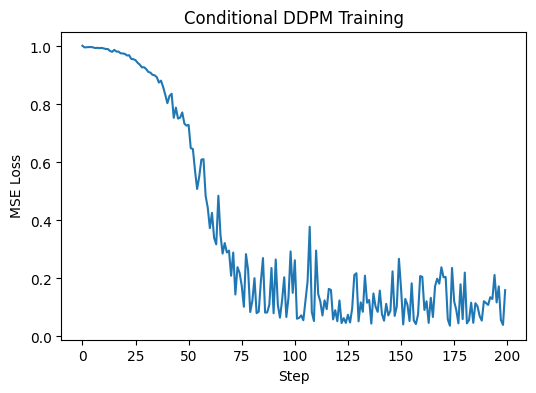

In [37]:
plt.figure(figsize=(6, 4))
plt.plot(cond_losses)
plt.xlabel("Step")
plt.ylabel("MSE Loss")
plt.title("Conditional DDPM Training")
plt.show()

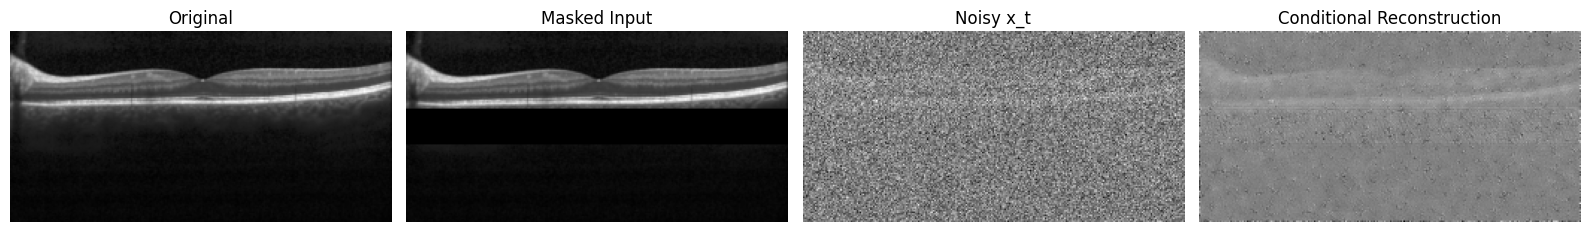

In [38]:
cond_model.eval()

with torch.no_grad():
    batch = next(iter(conditional_loader))
    
    x0 = batch["image"][:1].to(device)
    masked_image = batch["masked_image"][:1].to(device)
    mask = batch["mask"][:1].to(device)
    
    t = torch.tensor([250], device=device).long()
    
    noise = torch.randn_like(x0)
    
    x_t = q_sample(x0, t, noise)
    
    pred_noise = cond_model(
        x_t,
        masked_image,
        mask,
        t
    )
    
    alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1)
    
    x0_pred = (
        x_t
        -
        torch.sqrt(1.0 - alpha_bar_t) * pred_noise
    ) / torch.sqrt(alpha_bar_t)

# Convert to numpy

original_np = x0[0, 0].cpu().numpy()

masked_np = masked_image[0, 0].cpu().numpy()

noisy_np = x_t[0, 0].cpu().numpy()

recon_np = x0_pred[0, 0].cpu().numpy()

# Visualization

fig, axes = plt.subplots(1, 4, figsize=(16,4))

axes[0].imshow(original_np, cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(masked_np, cmap="gray")
axes[1].set_title("Masked Input")
axes[1].axis("off")

axes[2].imshow(noisy_np, cmap="gray")
axes[2].set_title("Noisy x_t")
axes[2].axis("off")

axes[3].imshow(recon_np, cmap="gray")
axes[3].set_title("Conditional Reconstruction")
axes[3].axis("off")

plt.tight_layout()
plt.show()

In [39]:
# Smaller diffusion schedule for CPU-friendly sampling

T_SAMPLE = 100

betas_sample = torch.linspace(
    beta_start,
    beta_end,
    T_SAMPLE
).to(device)

alphas_sample = 1.0 - betas_sample

alpha_bars_sample = torch.cumprod(
    alphas_sample,
    dim=0
)

print("Sampling timesteps:", T_SAMPLE)
print("alpha_bar final:", alpha_bars_sample[-1].item())

Sampling timesteps: 100
alpha_bar final: 0.3635632395744324


In [40]:
# Fast DDIM-style conditional sampling
@torch.no_grad()
def sample_conditional_inpaint(
    model,
    masked_image,
    mask,
    sample_steps=100
):
    model.eval()
    
    x = torch.randn_like(masked_image)
    x = mask * masked_image + (1 - mask) * x
    
    timesteps = torch.linspace(
        T - 1,
        0,
        sample_steps,
        device=device
    ).long()
    
    for i in tqdm(range(len(timesteps) - 1)):
        t = timesteps[i]
        t_prev = timesteps[i + 1]
        
        t_batch = torch.full(
            (x.shape[0],),
            t,
            device=device,
            dtype=torch.long
        )
        
        pred_noise = model(
            x,
            masked_image,
            mask,
            t_batch
        )
        
        alpha_bar_t = alpha_bars[t].view(1, 1, 1, 1)
        alpha_bar_prev = alpha_bars[t_prev].view(1, 1, 1, 1)
        
        x0_pred = (
            x - torch.sqrt(1.0 - alpha_bar_t) * pred_noise
        ) / torch.sqrt(alpha_bar_t)
        
        x = (
            torch.sqrt(alpha_bar_prev) * x0_pred
            +
            torch.sqrt(1.0 - alpha_bar_prev) * pred_noise
        )

        x = mask * masked_image + (1 - mask) * x
    
    return x.clamp(0, 1)

  0%|          | 0/99 [00:00<?, ?it/s]

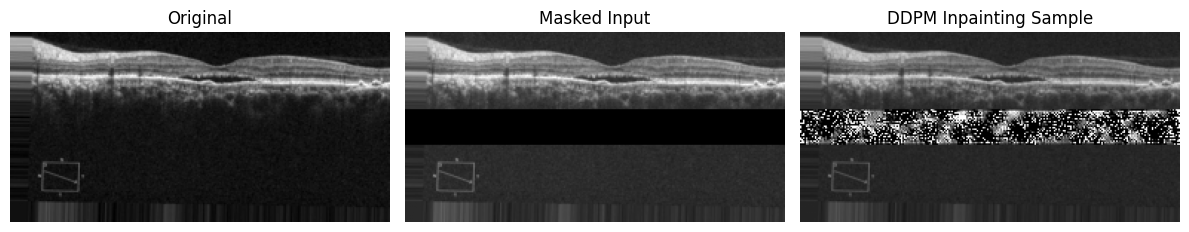

In [41]:
batch = next(iter(conditional_loader))

x0 = batch["image"][:1].to(device)
masked_image = batch["masked_image"][:1].to(device)
mask = batch["mask"][:1].to(device)

sampled_recon = sample_conditional_inpaint(
    cond_model,
    masked_image,
    mask,
    sample_steps=100
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x0[0, 0].cpu().numpy(), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(masked_image[0, 0].cpu().numpy(), cmap="gray")
axes[1].set_title("Masked Input")
axes[1].axis("off")

axes[2].imshow(sampled_recon[0, 0].cpu().numpy(), cmap="gray")
axes[2].set_title("DDPM Inpainting Sample")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [43]:
cond_model.train()

n_steps = 1000
cond_losses_long = []

data_iter = iter(conditional_loader)

for step in range(n_steps):
    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(conditional_loader)
        batch = next(data_iter)
    
    x0 = batch["image"].to(device)
    masked_image = batch["masked_image"].to(device)
    mask = batch["mask"].to(device)
    
    batch_size = x0.shape[0]
    
    t = torch.randint(0, T, (batch_size,), device=device).long()
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)
    
    pred_noise = cond_model(x_t, masked_image, mask, t)
    loss = loss_fn(pred_noise, noise)
    
    cond_optimizer.zero_grad()
    loss.backward()
    cond_optimizer.step()
    
    cond_losses_long.append(loss.item())
    
    if (step + 1) % 100 == 0:
        print(f"Step {step+1:04d} | Loss: {loss.item():.6f}")

Step 0100 | Loss: 0.073256
Step 0200 | Loss: 0.105764
Step 0300 | Loss: 0.026276
Step 0400 | Loss: 0.106713
Step 0500 | Loss: 0.026249
Step 0600 | Loss: 0.023907
Step 0700 | Loss: 0.035600
Step 0800 | Loss: 0.019813
Step 0900 | Loss: 0.040305
Step 1000 | Loss: 0.013276


  0%|          | 0/99 [00:00<?, ?it/s]

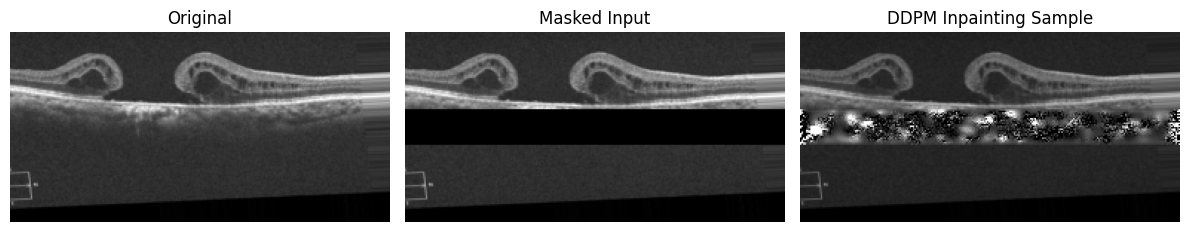

In [44]:
batch = next(iter(conditional_loader))

x0 = batch["image"][:1].to(device)
masked_image = batch["masked_image"][:1].to(device)
mask = batch["mask"][:1].to(device)

sampled_recon = sample_conditional_inpaint(
    cond_model,
    masked_image,
    mask,
    sample_steps=100
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x0[0, 0].cpu().numpy(), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(masked_image[0, 0].cpu().numpy(), cmap="gray")
axes[1].set_title("Masked Input")
axes[1].axis("off")

axes[2].imshow(sampled_recon[0, 0].cpu().numpy(), cmap="gray")
axes[2].set_title("DDPM Inpainting Sample")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [45]:
cond_model = ConditionalTimeDDPM().to(device)

cond_optimizer = torch.optim.Adam(
    cond_model.parameters(),
    lr=1e-4
)

loss_fn = nn.MSELoss()

In [46]:
cond_model.train()

n_steps = 1000
cond_losses_masked = []

data_iter = iter(conditional_loader)

for step in range(n_steps):
    try:
        batch = next(data_iter)
    except StopIteration:
        data_iter = iter(conditional_loader)
        batch = next(data_iter)
    
    x0 = batch["image"].to(device)
    masked_image = batch["masked_image"].to(device)
    mask = batch["mask"].to(device)
    
    batch_size = x0.shape[0]
    
    t = torch.randint(0, T, (batch_size,), device=device).long()
    noise = torch.randn_like(x0)
    x_t = q_sample(x0, t, noise)
    
    pred_noise = cond_model(x_t, masked_image, mask, t)
    
    missing_region = 1.0 - mask
    
    loss = (((pred_noise - noise) ** 2) * missing_region).sum() / missing_region.sum()
    
    cond_optimizer.zero_grad()
    loss.backward()
    cond_optimizer.step()
    
    cond_losses_masked.append(loss.item())
    
    if (step + 1) % 100 == 0:
        print(f"Step {step+1:04d} | Masked Loss: {loss.item():.6f}")

Step 0100 | Masked Loss: 0.052294
Step 0200 | Masked Loss: 0.126346
Step 0300 | Masked Loss: 0.097732
Step 0400 | Masked Loss: 0.016363
Step 0500 | Masked Loss: 0.050252
Step 0600 | Masked Loss: 0.021295
Step 0700 | Masked Loss: 0.025661
Step 0800 | Masked Loss: 0.123475
Step 0900 | Masked Loss: 0.025569
Step 1000 | Masked Loss: 0.015955


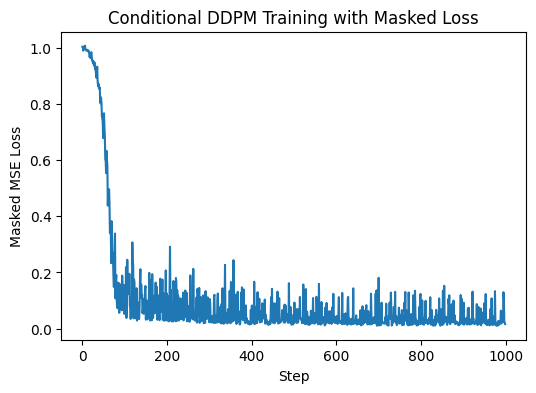

In [47]:
plt.figure(figsize=(6, 4))
plt.plot(cond_losses_masked)
plt.xlabel("Step")
plt.ylabel("Masked MSE Loss")
plt.title("Conditional DDPM Training with Masked Loss")
plt.show()

  0%|          | 0/99 [00:00<?, ?it/s]

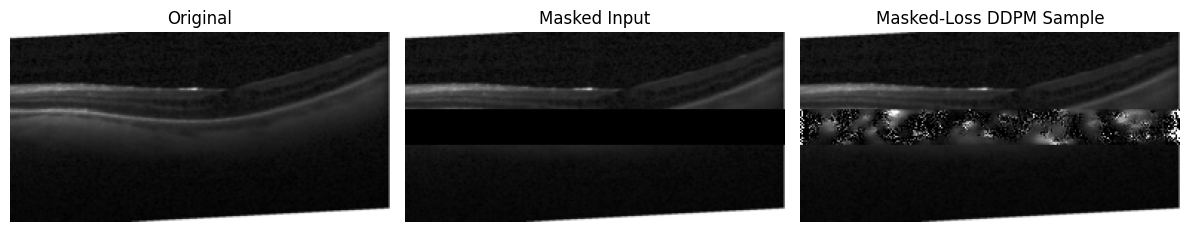

In [48]:
batch = next(iter(conditional_loader))

x0 = batch["image"][:1].to(device)
masked_image = batch["masked_image"][:1].to(device)
mask = batch["mask"][:1].to(device)

sampled_recon = sample_conditional_inpaint(
    cond_model,
    masked_image,
    mask,
    sample_steps=100
)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(x0[0, 0].cpu().numpy(), cmap="gray")
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(masked_image[0, 0].cpu().numpy(), cmap="gray")
axes[1].set_title("Masked Input")
axes[1].axis("off")

axes[2].imshow(sampled_recon[0, 0].cpu().numpy(), cmap="gray")
axes[2].set_title("Masked-Loss DDPM Sample")
axes[2].axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# TODO: increase training for stability

In [49]:
CHECKPOINT_DIR = Path("/Users/jonathanma/Desktop/DS Projects/diff-in-eye/results")
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

checkpoint_path = CHECKPOINT_DIR / "conditional_ddpm_masked_loss_1000steps.pt"

torch.save(
    {
        "model_state_dict": cond_model.state_dict(),
        "optimizer_state_dict": cond_optimizer.state_dict(),
        "losses": cond_losses_masked,
        "target_size": TARGET_SIZE,
        "T": T,
        "beta_start": beta_start,
        "beta_end": beta_end,
        "stripe_height": 24,
    },
    checkpoint_path
)

print(f"Saved checkpoint to: {checkpoint_path}")

Saved checkpoint to: /Users/jonathanma/Desktop/DS Projects/diff-in-eye/results/conditional_ddpm_masked_loss_1000steps.pt
